In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


import warnings
warnings.filterwarnings('ignore')

In [5]:
import pandas as pd
import numpy as np
from scipy.io import arff

In [6]:
from scipy.io import arff
import pandas as pd
data, meta = arff.loadarff(r'C:\Users\MNR\OneDrive\Desktop\AU-MCA\ML-Lab\file20385235375a.arff')
df = pd.DataFrame(data)
print(df.head())

    Xloc   Yloc  Landuse_1  Landuse_2  Landuse_3  Landuse_4  Rock_1  Rock_2  \
0  2.386  3.077        0.0        0.0        1.0        0.0     0.0     0.0   
1  2.544  1.972        0.0        1.0        0.0        0.0     0.0     1.0   
2  2.807  3.347        0.0        1.0        0.0        0.0     0.0     0.0   
3  4.308  1.933        0.0        0.0        1.0        0.0     0.0     1.0   
4  4.383  1.081        0.0        0.0        1.0        0.0     0.0     0.0   

   Rock_3  Rock_4  Rock_5     Cr     Ni     Pb     Zn     Cd     Co     Cu  
0     1.0     0.0     0.0  38.32  21.32  77.36  92.56  1.740   9.32  25.72  
1     0.0     0.0     0.0  40.20  29.72  77.88  73.56  1.335  10.00  24.76  
2     1.0     0.0     0.0  47.00  21.40  30.80  64.80  1.610  10.60   8.88  
3     0.0     0.0     0.0  43.52  29.72  56.40  90.00  2.150  11.92  22.70  
4     0.0     0.0     1.0  38.52  26.20  66.40  88.40  1.565  16.32  34.32  


In [7]:

jura = fetch_openml(data_id=41554, as_frame=True)

df = jura.frame

In [8]:
df.head()


,Xloc,Yloc,Landuse_1,Landuse_2,Landuse_3,Landuse_4,Rock_1,Rock_2,Rock_3,Rock_4,Rock_5,Cr,Ni,Pb,Zn,Cd,Co,Cu
0,2.386,3.077,0,0,1,0,0,0,1,0,0,38.32,21.32,77.36,92.56,1.740,9.32,25.72
1,2.544,1.972,0,1,0,0,0,1,0,0,0,40.20,29.72,77.88,73.56,1.335,10.00,24.76
2,2.807,3.347,0,1,0,0,0,0,1,0,0,47.00,21.40,30.80,64.80,1.610,10.60,8.88
3,4.308,1.933,0,0,1,0,0,1,0,0,0,43.52,29.72,56.40,90.00,2.150,11.92,22.70
4,4.383,1.081,0,0,1,0,0,0,0,0,1,38.52,26.20,66.40,88.40,1.565,16.32,34.32


In [9]:
print("Dataset Shape:", df.shape)

Dataset Shape: (359, 18)


In [10]:
df.tail()


,Xloc,Yloc,Landuse_1,Landuse_2,Landuse_3,Landuse_4,Rock_1,Rock_2,Rock_3,Rock_4,Rock_5,Cr,Ni,Pb,Zn,Cd,Co,Cu
354,4.248,2.489,1,0,0,0,0,0,0,1,0,27.04,21.04,48.80,46.40,1.220,5.24,5.52
355,3.784,3.677,1,0,0,0,0,1,0,0,0,28.32,18.00,34.32,55.20,0.640,13.92,6.68
356,4.324,2.835,1,0,0,0,0,1,0,0,0,33.36,22.72,60.00,80.00,1.650,8.72,8.88
357,3.859,4.022,0,0,1,0,0,0,1,0,0,47.60,29.12,60.80,87.20,1.433,13.32,43.60
358,2.593,3.312,0,0,1,0,0,0,1,0,0,30.00,14.00,26.20,54.96,0.325,10.60,8.08


In [11]:
df.describe()


,Xloc,Yloc,Landuse_1,Landuse_2,Landuse_3,Landuse_4,Rock_1,Rock_2,Rock_3,Rock_4,Rock_5,Cr,Ni,Pb,Zn,Cd,Co,Cu
count,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000
mean,2.963384,2.631769,0.142061,0.228412,0.607242,0.022284,0.211699,0.345404,0.247911,0.016713,0.178273,35.017827,20.018217,54.630975,75.881894,1.288237,9.439086,23.585471
std,0.980822,1.269089,0.349600,0.420396,0.489045,0.147812,0.409083,0.476163,0.432402,0.128373,0.383277,10.662561,8.094140,33.097935,30.818669,0.859098,3.568250,22.267948
min,0.491000,0.524000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.320000,1.980000,18.680000,25.000000,0.135000,1.552000,3.552000
25%,2.260500,1.510500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27.640000,14.600000,36.320000,54.600000,0.652500,6.660000,10.470000
50%,3.040000,2.489000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,34.800000,20.680000,46.800000,73.560000,1.100000,9.840000,17.200000
75%,3.674000,3.652000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,41.460000,25.380000,60.200000,90.000000,1.680000,12.100000,26.920000
max,4.920000,5.690000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,53.200000,300.000000,259.840000,5.129000,20.600000,166.400000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359 entries, 0 to 358
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Xloc       359 non-null    float64
 1   Yloc       359 non-null    float64
 2   Landuse_1  359 non-null    int64  
 3   Landuse_2  359 non-null    int64  
 4   Landuse_3  359 non-null    int64  
 5   Landuse_4  359 non-null    int64  
 6   Rock_1     359 non-null    int64  
 7   Rock_2     359 non-null    int64  
 8   Rock_3     359 non-null    int64  
 9   Rock_4     359 non-null    int64  
 10  Rock_5     359 non-null    int64  
 11  Cr         359 non-null    float64
 12  Ni         359 non-null    float64
 13  Pb         359 non-null    float64
 14  Zn         359 non-null    float64
 15  Cd         359 non-null    float64
 16  Co         359 non-null    float64
 17  Cu         359 non-null    float64
dtypes: float64(9), int64(9)
memory usage: 50.6 KB


In [13]:
df.shape


(359, 18)

In [14]:
df.isnull().sum()



Xloc         0
Yloc         0
Landuse_1    0
Landuse_2    0
Landuse_3    0
Landuse_4    0
Rock_1       0
Rock_2       0
Rock_3       0
Rock_4       0
Rock_5       0
Cr           0
Ni           0
Pb           0
Zn           0
Cd           0
Co           0
Cu           0
dtype: int64

In [15]:
df = df.applymap(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

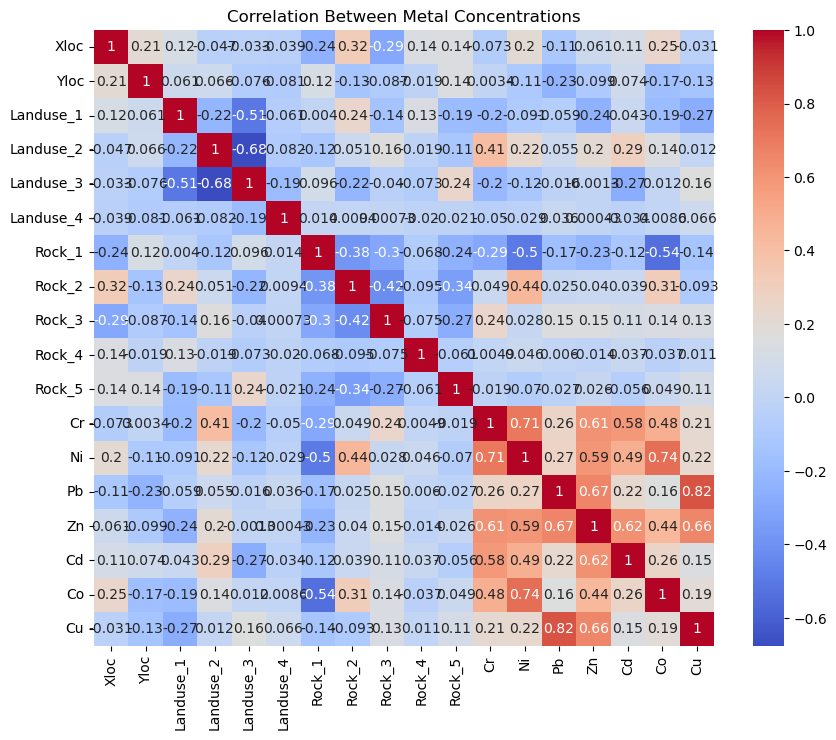

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Metal Concentrations")
plt.show()




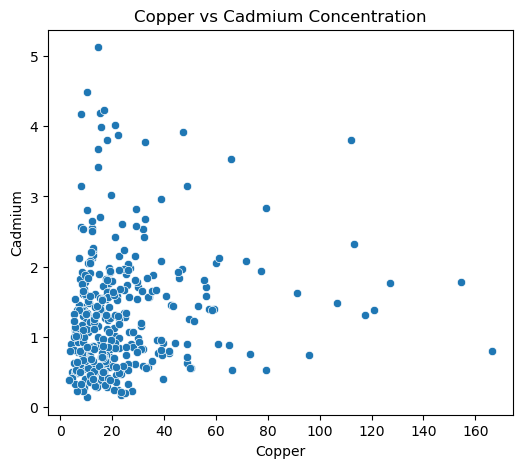

In [17]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=df['Cu'], y=df['Cd'])
plt.title("Copper vs Cadmium Concentration")
plt.xlabel("Copper")
plt.ylabel("Cadmium")
plt.show()

In [18]:

Y = df['Cd']
X = df.drop(columns=['Cd'])
print("Features Shape:", X.shape)


Features Shape: (359, 17)


In [19]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X)

print("Polynomial Feature Shape:", X_poly.shape)

Polynomial Feature Shape: (359, 170)


In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=42
)


In [22]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [23]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

Ridge()

In [24]:
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)

Lasso()

In [25]:
y_pred_linear = linear_model.predict(X_test)
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

In [26]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name}")
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("--------------------")
    

In [27]:
evaluate_model(y_test, y_pred_linear, "Linear Regression")
evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
evaluate_model(y_test, y_pred_lasso, "Lasso Regression")


Linear Regression
RMSE: 0.832847080894298
R2 Score: -0.0689754155272937
--------------------
Ridge Regression
RMSE: 0.5436805249582771
R2 Score: 0.5444618700450954
--------------------
Lasso Regression
RMSE: 0.8087172166439488
R2 Score: -0.007930435176925155
--------------------


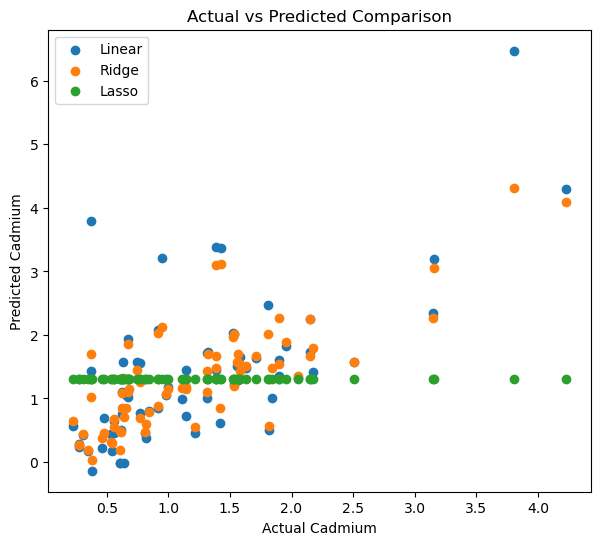

In [28]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred_linear, label="Linear")
plt.scatter(y_test, y_pred_ridge, label="Ridge")
plt.scatter(y_test, y_pred_lasso, label="Lasso")

plt.xlabel("Actual Cadmium")
plt.ylabel("Predicted Cadmium")
plt.title("Actual vs Predicted Comparison")
plt.legend()
plt.show()

In [29]:
coefficients = pd.DataFrame({
    "Linear": linear_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_
})

coefficients.head()

,Linear,Ridge,Lasso
0,-0.152636,-0.103323,0.0
1,0.435489,0.273962,0.0
2,0.041790,0.035740,0.0
3,-0.066659,-0.005692,0.0
4,0.010552,-0.026580,-0.0


In [30]:
zero_features = np.sum(lasso_model.coef_ == 0)

print("Number of features reduced to zero by Lasso:", zero_features)

Number of features reduced to zero by Lasso: 170


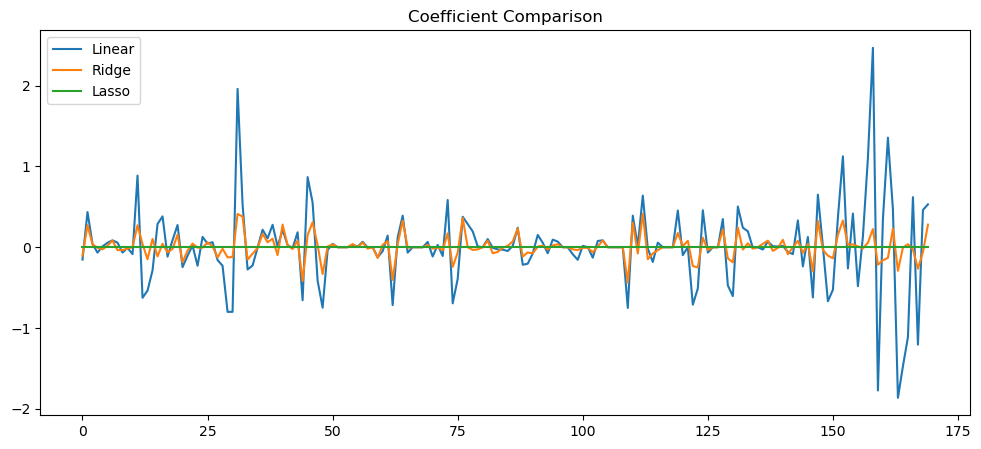

In [31]:
plt.figure(figsize=(12,5))
plt.plot(linear_model.coef_, label="Linear")
plt.plot(ridge_model.coef_, label="Ridge")
plt.plot(lasso_model.coef_, label="Lasso")

plt.title("Coefficient Comparison")
plt.legend()
plt.show()

In [32]:
from sklearn.datasets import fetch_openml

jura = fetch_openml(data_id=41554, as_frame=True)
df = jura.frame

print(df.head())

    Xloc   Yloc  Landuse_1  Landuse_2  Landuse_3  Landuse_4  Rock_1  Rock_2  \
0  2.386  3.077          0          0          1          0       0       0   
1  2.544  1.972          0          1          0          0       0       1   
2  2.807  3.347          0          1          0          0       0       0   
3  4.308  1.933          0          0          1          0       0       1   
4  4.383  1.081          0          0          1          0       0       0   

   Rock_3  Rock_4  Rock_5     Cr     Ni     Pb     Zn     Cd     Co     Cu  
0       1       0       0  38.32  21.32  77.36  92.56  1.740   9.32  25.72  
1       0       0       0  40.20  29.72  77.88  73.56  1.335  10.00  24.76  
2       1       0       0  47.00  21.40  30.80  64.80  1.610  10.60   8.88  
3       0       0       0  43.52  29.72  56.40  90.00  2.150  11.92  22.70  
4       0       0       1  38.52  26.20  66.40  88.40  1.565  16.32  34.32  


In [33]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml

# Load dataset from OpenML
jura = fetch_openml(data_id=41554, as_frame=True)

# Convert to DataFrame
df = jura.frame

# Display first 5 rows
print("First 5 Rows:")
display(df.head())

# Summary statistics
print("\nSummary Statistics:")
display(df.describe())


First 5 Rows:


,Xloc,Yloc,Landuse_1,Landuse_2,Landuse_3,Landuse_4,Rock_1,Rock_2,Rock_3,Rock_4,Rock_5,Cr,Ni,Pb,Zn,Cd,Co,Cu
0,2.386,3.077,0,0,1,0,0,0,1,0,0,38.32,21.32,77.36,92.56,1.740,9.32,25.72
1,2.544,1.972,0,1,0,0,0,1,0,0,0,40.20,29.72,77.88,73.56,1.335,10.00,24.76
2,2.807,3.347,0,1,0,0,0,0,1,0,0,47.00,21.40,30.80,64.80,1.610,10.60,8.88
3,4.308,1.933,0,0,1,0,0,1,0,0,0,43.52,29.72,56.40,90.00,2.150,11.92,22.70
4,4.383,1.081,0,0,1,0,0,0,0,0,1,38.52,26.20,66.40,88.40,1.565,16.32,34.32



Summary Statistics:


,Xloc,Yloc,Landuse_1,Landuse_2,Landuse_3,Landuse_4,Rock_1,Rock_2,Rock_3,Rock_4,Rock_5,Cr,Ni,Pb,Zn,Cd,Co,Cu
count,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000
mean,2.963384,2.631769,0.142061,0.228412,0.607242,0.022284,0.211699,0.345404,0.247911,0.016713,0.178273,35.017827,20.018217,54.630975,75.881894,1.288237,9.439086,23.585471
std,0.980822,1.269089,0.349600,0.420396,0.489045,0.147812,0.409083,0.476163,0.432402,0.128373,0.383277,10.662561,8.094140,33.097935,30.818669,0.859098,3.568250,22.267948
min,0.491000,0.524000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.320000,1.980000,18.680000,25.000000,0.135000,1.552000,3.552000
25%,2.260500,1.510500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27.640000,14.600000,36.320000,54.600000,0.652500,6.660000,10.470000
50%,3.040000,2.489000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,34.800000,20.680000,46.800000,73.560000,1.100000,9.840000,17.200000
75%,3.674000,3.652000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,41.460000,25.380000,60.200000,90.000000,1.680000,12.100000,26.920000
max,4.920000,5.690000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,53.200000,300.000000,259.840000,5.129000,20.600000,166.400000


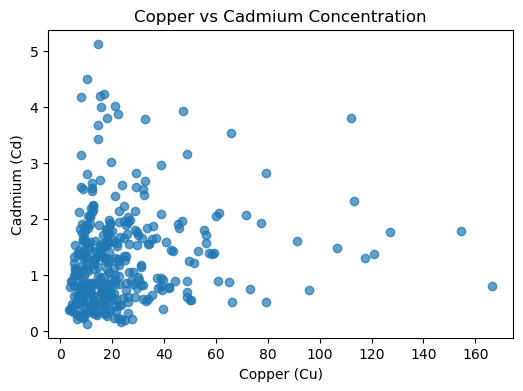

In [34]:
# Scatter plot
plt.figure(figsize=(6,4))
plt.scatter(df['Cu'], df['Cd'], alpha=0.7)
plt.xlabel("Copper (Cu)")
plt.ylabel("Cadmium (Cd)")
plt.title("Copper vs Cadmium Concentration")
plt.show()

In [35]:
y_pred_linear = linear_model.predict(X_test)
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

In [36]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name}")
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("----------------------")

evaluate("Linear Regression", y_test, y_pred_linear)
evaluate("Ridge Regression", y_test, y_pred_ridge)
evaluate("Lasso Regression", y_test, y_pred_lasso)


Linear Regression
RMSE: 0.832847080894298
R2 Score: -0.0689754155272937
----------------------
Ridge Regression
RMSE: 0.5436805249582771
R2 Score: 0.5444618700450954
----------------------
Lasso Regression
RMSE: 0.8087172166439488
R2 Score: -0.007930435176925155
----------------------


In [37]:
print("Linear Coefficients:")
print(linear_model.coef_)

print("\nRidge Coefficients:")
print(ridge_model.coef_)

print("\nLasso Coefficients:")
print(lasso_model.coef_)

Linear Coefficients:
[-1.52636106e-01  4.35489373e-01  4.17901890e-02 -6.66587332e-02
  1.05519664e-02  5.58329578e-02  8.56176263e-02  5.69267814e-02
 -6.57678219e-02 -8.22630949e-03 -8.51524800e-02  8.86594978e-01
 -6.25355180e-01 -5.36648895e-01 -2.86524139e-01  2.88164528e-01
  3.81827806e-01 -1.16107267e-01  8.79875674e-02  2.75238893e-01
 -2.45799755e-01 -1.04820650e-01  2.14590718e-02 -2.28898257e-01
  1.27735788e-01  4.49287726e-02  6.22322894e-02 -1.57998299e-01
 -2.29803299e-01 -7.99946738e-01 -7.98999718e-01  1.96001005e+00
  5.32211123e-01 -2.75045908e-01 -2.25703242e-01 -4.22650387e-03
  2.17299432e-01  1.09882955e-01  2.77746390e-01  9.48857911e-03
  2.15910942e-01  2.55054165e-02 -9.88379853e-03  1.85739321e-01
 -6.56017301e-01  8.67833029e-01  5.52332928e-01 -4.14582694e-01
 -7.47936820e-01 -3.38991789e-02  4.17901890e-02  2.08166817e-16
  2.66453526e-15 -9.15933995e-16  2.77796239e-02  7.69157662e-03
  6.75088490e-02 -3.30806015e-03  2.33146835e-15 -1.23014582e-01
 -4.

In [38]:
# Get feature names
feature_names = poly.get_feature_names_out(X.columns)

lasso_coeff = pd.Series(lasso_model.coef_, index=feature_names)

zero_features = lasso_coeff[lasso_coeff == 0]

print("Features eliminated by Lasso:")
print(zero_features.index.tolist())


Features eliminated by Lasso:
['Xloc', 'Yloc', 'Landuse_1', 'Landuse_2', 'Landuse_3', 'Landuse_4', 'Rock_1', 'Rock_2', 'Rock_3', 'Rock_4', 'Rock_5', 'Cr', 'Ni', 'Pb', 'Zn', 'Co', 'Cu', 'Xloc^2', 'Xloc Yloc', 'Xloc Landuse_1', 'Xloc Landuse_2', 'Xloc Landuse_3', 'Xloc Landuse_4', 'Xloc Rock_1', 'Xloc Rock_2', 'Xloc Rock_3', 'Xloc Rock_4', 'Xloc Rock_5', 'Xloc Cr', 'Xloc Ni', 'Xloc Pb', 'Xloc Zn', 'Xloc Co', 'Xloc Cu', 'Yloc^2', 'Yloc Landuse_1', 'Yloc Landuse_2', 'Yloc Landuse_3', 'Yloc Landuse_4', 'Yloc Rock_1', 'Yloc Rock_2', 'Yloc Rock_3', 'Yloc Rock_4', 'Yloc Rock_5', 'Yloc Cr', 'Yloc Ni', 'Yloc Pb', 'Yloc Zn', 'Yloc Co', 'Yloc Cu', 'Landuse_1^2', 'Landuse_1 Landuse_2', 'Landuse_1 Landuse_3', 'Landuse_1 Landuse_4', 'Landuse_1 Rock_1', 'Landuse_1 Rock_2', 'Landuse_1 Rock_3', 'Landuse_1 Rock_4', 'Landuse_1 Rock_5', 'Landuse_1 Cr', 'Landuse_1 Ni', 'Landuse_1 Pb', 'Landuse_1 Zn', 'Landuse_1 Co', 'Landuse_1 Cu', 'Landuse_2^2', 'Landuse_2 Landuse_3', 'Landuse_2 Landuse_4', 'Landuse_2 Rock